In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, '../src')
from deploy_policy import PolicyEvaluator
import yaml
import utils
import matplotlib


In [6]:





def plot_belief_space(file_path, l_to_plot=1, tick_step=2, belief_range=10):



    # Load data
    data = torch.load(file_path, weights_only=False)


    # Print initial-state summary statistics
    p_approval = data['P_approval'][0][0, 0]
    a_initial  = data['A'][0][0, 0]
    params = data.get('params', {})
    alpha_0 = params.get('alpha_0', 1.0)
    beta_0 = params.get('beta_0', 1.0)
    n_max = params.get('n_max', 150)
    print(f"P(approval | α₀={alpha_0}, β₀={beta_0}, l=0) = {p_approval:.4f}")
    print(f"E[total cost | approved, α₀={alpha_0}, β₀={beta_0}, l=0] = {a_initial:.4f}")

    # Grid data for the chosen time step
    v_grid = data['V_eps'][l_to_plot]
    p_grid = data['Policy'][l_to_plot]

    # N is the cumulative number of trials (the first dimension of our saved grid)
    max_N = v_grid.shape[0] - 1

    # The range of possible alpha and beta values given max_N
    # alpha can go from alpha_0 to alpha_0 + max_N
    # beta can go from beta_0 to beta_0 + max_N
    alpha_range = np.arange(alpha_0, alpha_0 + max_N + 1)
    beta_range = np.arange(beta_0, beta_0 + max_N + 1)

    # Create the (alpha, beta) visualization grid
    v_belief = np.full((len(beta_range), len(alpha_range)), np.nan)
    p_belief = np.full((len(beta_range), len(alpha_range)), np.nan)

    # Map each (N, X) state in the solver to its (alpha, beta) coordinates
    for n in range(v_grid.shape[0]):
        for x in range(v_grid.shape[1]):
            if x > n: continue # Impossible state

            # Belief update: alpha = alpha_0 + successes, beta = beta_0 + failures
            curr_alpha = alpha_0 + x
            curr_beta = beta_0 + (n - x)

            # Find the index in our visualization grid
            a_idx = int(curr_alpha - alpha_0)
            b_idx = int(curr_beta - beta_0)

            v_belief[b_idx, a_idx] = v_grid[n, x]
            p_belief[b_idx, a_idx] = p_grid[n, x]


    # Plotting

    plt.clf()
    sns.set_theme(context='paper', style='ticks', font_scale=1)
    width_pt = 1200
    palette = sns.color_palette('icefire', 3)

    utils.latexify()

    fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.6)
    fig, ax = plt.subplots(1,2, figsize=(fig_width, fig_height))

    #fig, ax = plt.subplots(1, 2, figsize=(18, 8))

    #plot only the first 10 alpha and beta values to focus on the most relevant region of the belief space
    alpha_range = alpha_range[:belief_range]
    beta_range = beta_range[:belief_range]
    v_belief = v_belief[:len(beta_range), :len(alpha_range)]
    p_belief = p_belief[:len(beta_range), :len(alpha_range)]
    # Define ticks
    x_ticks = np.arange(0, len(alpha_range), tick_step)
    y_ticks = np.arange(0, len(beta_range), tick_step)
    x_labels = alpha_range[x_ticks].astype(int)
    y_labels = beta_range[y_ticks].astype(int)

    # Plot Value Function
    sns.heatmap(v_belief, ax=ax[0], cmap='viridis', mask=np.isnan(v_belief))
    ax[0].set_xticks(x_ticks + 0.5); ax[0].set_xticklabels(x_labels)
    ax[0].set_yticks(y_ticks + 0.5); ax[0].set_yticklabels(y_labels)
    ax[0].set_title(f"Value Function in $(\\alpha, \\beta, l={l_to_plot}$)")
    ax[0].set_xlabel("$\\alpha$"); ax[0].set_ylabel("$\\beta$")
    ax[0].invert_yaxis()

    # Plot Policy
    # plot the optimal policy with the highest color being n_max and the lowest color being 0, with a colorbar legend
    norm = matplotlib.colors.Normalize(vmin=0, vmax=n_max)
    sns.heatmap(p_belief, ax=ax[1], cmap='cividis', mask=np.isnan(p_belief), norm=norm)
    ax[1].set_xticks(x_ticks + 0.5); ax[1].set_xticklabels(x_labels)
    ax[1].set_yticks(y_ticks + 0.5); ax[1].set_yticklabels(y_labels)
    ax[1].set_title(f"Optimal Policy (Sample Size $n$)")
    ax[1].set_xlabel("$\\alpha$"); ax[1].set_ylabel("$\\beta$")
    ax[1].invert_yaxis()

    plt.tight_layout()
    plt.show()
    fig.savefig('../figures/optimist_concentrated/mdp_output/belief_space.pdf', format='pdf', bbox_inches='tight')





def plot_belief_trajectories(results, evaluator, max_paths=300):
    """
    Plots belief trajectories (alpha, beta) in the plane.

    results: output of evaluator.evaluate()
    evaluator: the PolicyEvaluator instance used for evaluation
    max_paths: limit number of trajectories plotted (for readability)
    """

    belief_paths = results['belief_paths']

    plt.clf()
    sns.set_theme(context='paper', style='ticks', font_scale=1)
    width_pt = 1200
    palette = sns.color_palette('icefire', 3)

    utils.latexify()

    fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.6)
    fig, ax = plt.subplots(1,1, figsize=(fig_width, fig_height))

    # Subsample paths if too many
    paths_to_plot = belief_paths[:max_paths]

    all_alphas = []
    all_betas  = []

    for path in paths_to_plot:
        alphas = [ab[0] for ab in path]
        betas  = [ab[1] for ab in path]

        all_alphas.extend(alphas)
        all_betas.extend(betas)

        plt.plot(alphas, betas, color='blue', alpha=0.08, linewidth=1)

    # --- Make axes square and nicely bounded ---
    min_alpha, max_alpha = min(all_alphas), max(all_alphas)
    min_beta,  max_beta  = min(all_betas),  max(all_betas)

    lower = min(min_alpha, min_beta)
    upper = max(max_alpha, max_beta)

    # --- Compute boundary ---
    alpha_0 = evaluator.alpha_0
    beta_0  = evaluator.beta_0
    log_term = evaluator.log_term
    log_kappa_inv = evaluator.log_kappa_inv

    alpha_vals = np.linspace(lower, upper, 500)

    beta_boundary = (
        (1 - log_term) * alpha_vals
        + log_term * (alpha_0 + beta_0)
        - alpha_0
        - log_kappa_inv
    ) / log_term

    # --- Plot boundary ---
    plt.plot(alpha_vals, beta_boundary, color='green', linewidth=1)

    # --- Shade approval region ---
    # Approval is: beta <= boundary (given the inequality structure)
    plt.fill_between(
        alpha_vals,
        beta_boundary,
        lower,
        where=(beta_boundary >= lower),
        color='green',
        alpha=0.15
    )




    plt.xlim(lower, upper)
    plt.ylim(lower, upper)

    plt.gca().set_aspect('equal', adjustable='box')

    plt.xlabel(r'$\alpha$')
    plt.ylabel(r'$\beta$')
    plt.title('Belief Trajectories in $(\\alpha, \\beta)$ Space')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    fig.savefig('../figures/optimist_concentrated/mdp_output/belief_space_trajectories.pdf', format='pdf', bbox_inches='tight')





# ── Configure these ────────────────────────────────────────────────────────────
config_path = '../../config/optimist_concentrated.yaml'
policy_path = '../outputs/optimist_concentrated/mdp_output/mdp_results_eps_0.300_T_3_nmax_150_alpha_1.0_beta_1.0_thetab_0.4.pt'
theta_star  = 0.6    # true efficacy θ*
n_episodes  = 200_000
# ───────────────────────────────────────────────────────────────────────────────
with open(config_path) as f:
    config = yaml.safe_load(f)

evaluator = PolicyEvaluator(
    rho_A       = config['rho_A'],
    T           = config['T'],
    n_max       = config['n_max'],
    c0          = config['c0'],
    c1          = config['c1'],
    epsilon     = config['epsilon'],
    kappa       = config['kappa'],
    theta_b     = config['theta_b'],
    alpha_0     = config['alpha_0'],
    beta_0      = config['beta_0'],
    theta_star  = theta_star,
    policy_path = policy_path,
    n_episodes  = n_episodes,
)
results = evaluator.evaluate()


Loading policy from: ../outputs/optimist_concentrated/mdp_output/mdp_results_eps_0.300_T_3_nmax_150_alpha_1.0_beta_1.0_thetab_0.4.pt


P(approval | α₀=1.0, β₀=1.0, l=0) = 0.4272
E[total cost | approved, α₀=1.0, β₀=1.0, l=0] = 42.7612


<Figure size 640x480 with 0 Axes>

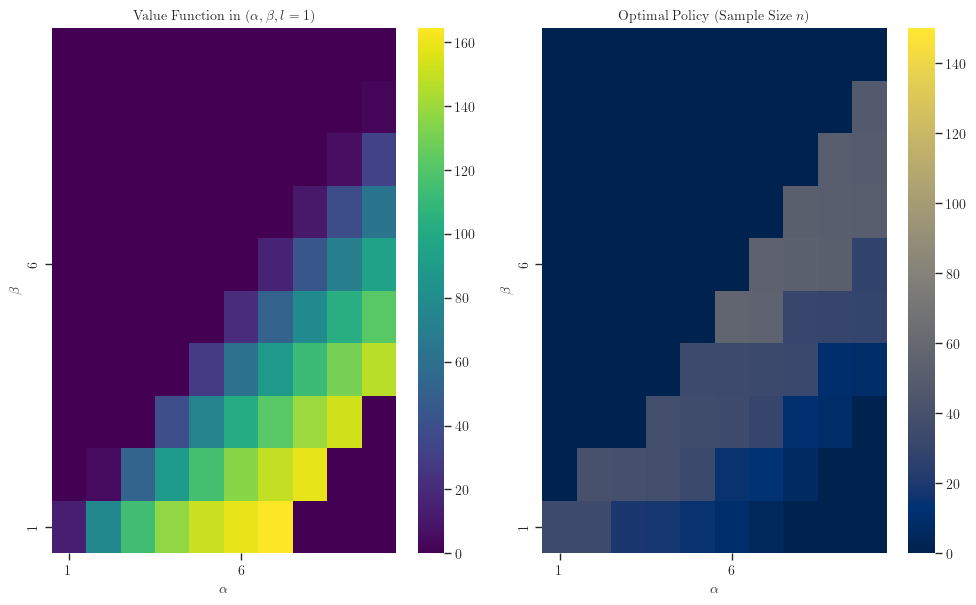

<Figure size 640x480 with 0 Axes>

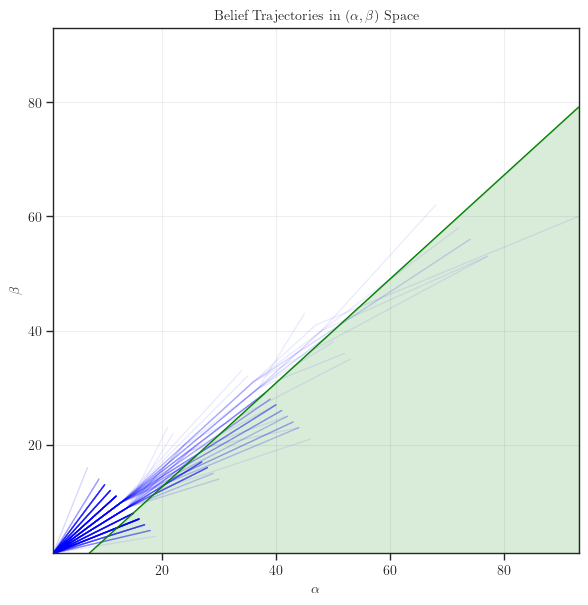

Policy evaluation under θ* = 0.6, ε = 0.3
  P(approval)              = 0.6486  (129,720 / 200,000)
  E[total cost | approved] = 176.3908
  Agent utility            = 4.6144


In [5]:
plot_belief_space("../../outputs/optimist_concentrated/mdp_output/mdp_results_eps_0.300_T_3_nmax_150_alpha_1.0_beta_1.0_thetab_0.4.pt", l_to_plot=1, tick_step=5, belief_range=10)

plot_belief_trajectories(results, evaluator)
print(f"Policy evaluation under θ* = {results['theta_star']}, ε = {results['epsilon']}")
print(f"  P(approval)              = {results['p_approval']:.4f}  ({results['n_approved']:,} / {results['n_episodes']:,})")
print(f"  E[total cost | approved] = {results['e_cost_given_approval']:.4f}")
print(f"  Agent utility            = {results['agent_utility']:.4f}")

# Plot Q values

In [ ]:

def plot_Q_values(file_path, states, l_to_plot=1, tick_step=5):
    """
    Plot Q(n) for n=1..n_max at specified (alpha, beta) belief states.

    Parameters
    ----------
    file_path : str
        Path to the saved .pt MDP results file.
    states : list of (alpha, beta) tuples
        Belief states to compare, e.g. [(3, 10), (3, 11)].
    l_to_plot : int
        Time step at which to evaluate Q(n). States reachable at l have N <= l*n_max.
    tick_step : int
        Step for x-axis ticks.
    """
    import math

    data   = torch.load(file_path, weights_only=False)
    params = data['params']
    alpha_0 = params['alpha_0']
    beta_0  = params['beta_0']
    kappa   = params['kappa']
    theta_b = params['theta_b']
    rho_A   = params['rho_A']
    epsilon = params['epsilon']
    c0      = params['c0']
    c1      = params['c1']
    T       = params['T']
    n_max   = params['n_max']

    log_kappa_inv = np.log(1.0 / kappa)
    log_term      = np.log(1.0 + theta_b * (np.e - 1.0))
    period        = 1.0 / log_term

    print(f"log(1 + θᵇ(e−1)) = {log_term:.6f}")
    print(f"Expected oscillation period = 1 / {log_term:.6f} ≈ {period:.2f} samples")

    def check_rejection_np(N, X):
        alpha = alpha_0 + X
        beta  = beta_0  + N - X
        lhs   = (alpha - alpha_0) - (alpha + beta - alpha_0 - beta_0) * log_term
        return lhs >= log_kappa_inv

    def bb_pmf(x_arr, n, alpha, beta):
        x = x_arr.astype(float)
        lp = (
            math.lgamma(n + 1)
            - np.array([math.lgamma(xi + 1) for xi in x])
            - np.array([math.lgamma(n - xi + 1) for xi in x])
            + np.array([math.lgamma(xi + alpha) for xi in x])
            + np.array([math.lgamma(n - xi + beta) for xi in x])
            - math.lgamma(n + alpha + beta)
            + math.lgamma(alpha + beta) - math.lgamma(alpha) - math.lgamma(beta)
        )
        return np.exp(lp)

    max_N_global = T * n_max
    V_next = data['V_eps'][l_to_plot + 1] if l_to_plot < T else np.zeros((max_N_global + 1, max_N_global + 1))
    actions = np.arange(1, n_max + 1)

    with plt.style.context('default'):
        fig, axes = plt.subplots(1, len(states), figsize=(7 * len(states), 5))
        if len(states) == 1:
            axes = [axes]

        for ax, (alpha_s, beta_s) in zip(axes, states):
            X = int(alpha_s - alpha_0)
            N = X + int(beta_s - beta_0)

            ax.set_xlim(1, n_max)
            ax.set_xticks(np.arange(1, n_max + 1, tick_step))
            ax.set_xlabel("Action n")
            ax.set_ylabel("Q(n)")
            ax.grid(True, alpha=0.3)

            if X < 0 or N < 0 or X > N:
                ax.set_title(f"α={alpha_s}, β={beta_s}  — invalid state (need α≥α₀, β≥β₀, α+β≥α₀+β₀)")
                continue
            if N > l_to_plot * n_max:
                ax.set_title(
                    f"α={alpha_s}, β={beta_s}  — unreachable at l={l_to_plot}\n"
                    f"(N={N} > l·n_max={l_to_plot*n_max}; try a larger l)"
                )
                continue

            C_curr = l_to_plot * c0 + N * c1
            Q_vals = np.full(len(actions), np.nan)

            for i, n in enumerate(actions):
                x_arr  = np.arange(0, int(n) + 1)
                pmf    = bb_pmf(x_arr, int(n), float(alpha_s), float(beta_s))
                cost_n = c0 + c1 * n
                C_next = C_curr + cost_n
                v_fut  = np.empty(len(x_arr))
                for j, nx in enumerate(x_arr):
                    nN, nX = N + int(n), X + int(nx)
                    if check_rejection_np(nN, nX):
                        v_fut[j] = rho_A + epsilon * C_next
                    else:
                        v_fut[j] = V_next[min(nN, max_N_global), min(nX, max_N_global)]
                Q_vals[i] = -cost_n + float(np.sum(pmf * v_fut))

            best_idx = int(np.nanargmax(Q_vals))
            best_Q   = Q_vals[best_idx]
            best_n   = actions[best_idx]
            opt_out  = best_Q <= 1e-15

            ax.plot(actions, Q_vals, lw=1.5, color='steelblue', label='Q(n)')
            ax.axhline(0, color='gray', lw=0.8, ls='--', label='opt-out threshold')
            if not opt_out:
                ax.axvline(best_n, color='tomato', lw=1.2, ls=':',
                           label=f'n*={best_n}  Q={best_Q:.4f}')
                ax.scatter([best_n], [best_Q], color='tomato', zorder=5)
            n_str = '0 (opt-out)' if opt_out else str(best_n)
            ax.set_title(f"α={alpha_s}, β={beta_s}  |  l={l_to_plot}  →  n*={n_str}")
            ax.legend(fontsize=8)

        plt.suptitle(
            f"Q(n) = −c(n) + 𝔼[V^ε_{{l+1}} | n, α, β]"
            f"   |   oscillation period ≈ 1/log(1+θᵇ(e−1)) = {period:.2f}",
            fontsize=12
        )
        plt.tight_layout()
        plt.show()


# ── Edit these two states ──────────────────────────────────────────────────────
state1 = (7, 4)   # (alpha, beta)
state2 = (7, 5)   # (alpha, beta)  ← β+1 neighbour with suspicious policy jump
# ───────────────────────────────────────────────────────────────────────────────

plot_Q_values(
    '../outputs/mdp_output/mdp_results_eps_0.000_T_1_nmax_100.pt',
    states=[state1, state2],
    l_to_plot=1,
    tick_step=5,
)


In [ ]:

def measure_Q_oscillation_period(file_path, alpha_s, beta_s, l_to_plot=1):
    """
    Compute the empirical oscillation period of Q(n) by measuring peak spacings,
    and compare to the theoretical prediction 1 / log(1 + θᵇ(e−1)).
    """
    import math
    from scipy.signal import find_peaks

    data   = torch.load(file_path, weights_only=False)
    params = data['params']
    alpha_0 = params['alpha_0']
    beta_0  = params['beta_0']
    kappa   = params['kappa']
    theta_b = params['theta_b']
    rho_A   = params['rho_A']
    epsilon = params['epsilon']
    c0      = params['c0']
    c1      = params['c1']
    T       = params['T']
    n_max   = params['n_max']

    log_kappa_inv  = np.log(1.0 / kappa)
    log_term       = np.log(1.0 + theta_b * (np.e - 1.0))
    period_theory  = 1.0 / log_term

    def check_rejection_np(N, X):
        lhs = (alpha_0 + X - alpha_0) - (N - 0) * log_term  # simplified: X - N*log_term
        # full form to stay consistent with solver
        alpha = alpha_0 + X
        beta  = beta_0  + N - X
        lhs   = (alpha - alpha_0) - (alpha + beta - alpha_0 - beta_0) * log_term
        return lhs >= log_kappa_inv

    def bb_pmf(x_arr, n, alpha, beta):
        x = x_arr.astype(float)
        lp = (
            math.lgamma(n + 1)
            - np.array([math.lgamma(xi + 1) for xi in x])
            - np.array([math.lgamma(n - xi + 1) for xi in x])
            + np.array([math.lgamma(xi + alpha) for xi in x])
            + np.array([math.lgamma(n - xi + beta) for xi in x])
            - math.lgamma(n + alpha + beta)
            + math.lgamma(alpha + beta) - math.lgamma(alpha) - math.lgamma(beta)
        )
        return np.exp(lp)

    max_N_global = T * n_max
    V_next = data['V_eps'][l_to_plot + 1] if l_to_plot < T else np.zeros((max_N_global + 1, max_N_global + 1))
    actions = np.arange(1, n_max + 1)

    X = int(alpha_s - alpha_0)
    N = X + int(beta_s - beta_0)
    C_curr = l_to_plot * c0 + N * c1

    Q_vals = np.full(len(actions), np.nan)
    for i, n in enumerate(actions):
        x_arr  = np.arange(0, int(n) + 1)
        pmf    = bb_pmf(x_arr, int(n), float(alpha_s), float(beta_s))
        cost_n = c0 + c1 * n
        C_next = C_curr + cost_n
        v_fut  = np.empty(len(x_arr))
        for j, nx in enumerate(x_arr):
            nN, nX = N + int(n), X + int(nx)
            if check_rejection_np(nN, nX):
                v_fut[j] = rho_A + epsilon * C_next
            else:
                v_fut[j] = V_next[min(nN, max_N_global), min(nX, max_N_global)]
        Q_vals[i] = -cost_n + float(np.sum(pmf * v_fut))

    # ── Find peaks ────────────────────────────────────────────────────────────
    # Use a minimum distance slightly below the theoretical period so we don't
    # skip peaks, but large enough to ignore sub-sample noise.
    min_dist = max(1, int(0.5 * period_theory))
    peaks, _ = find_peaks(Q_vals, distance=min_dist)
    spacings = np.diff(peaks)

    print(f"State: α={alpha_s}, β={beta_s},  l={l_to_plot}")
    print(f"  Theoretical period  = 1 / log(1+θᵇ(e−1)) = {period_theory:.4f}")
    if len(spacings) == 0:
        print("  Not enough peaks found to measure empirical period.")
    else:
        print(f"  Peaks found at n = {peaks + 1}")   # +1 because actions start at 1
        print(f"  Peak spacings    = {spacings}")
        print(f"  Mean spacing     = {spacings.mean():.4f}  (std = {spacings.std():.4f})")
        print(f"  Ratio empirical/theoretical = {spacings.mean() / period_theory:.4f}")

    # ── Plot ──────────────────────────────────────────────────────────────────
    with plt.style.context('default'):
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(actions, Q_vals, lw=1.2, color='steelblue', label='Q(n)')
        ax.scatter(peaks + 1, Q_vals[peaks], color='tomato', zorder=5,
                   label=f'peaks (n={peaks+1})')
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        # Annotate spacing between consecutive peaks
        for i in range(len(peaks) - 1):
            mid = (peaks[i] + peaks[i+1]) / 2
            sp  = spacings[i]
            ax.annotate(f'Δ={sp}', xy=(mid + 1, Q_vals[peaks[i]] * 0.97),
                        ha='center', fontsize=7, color='dimgray')
        ax.set_xlabel("Action n")
        ax.set_ylabel("Q(n)")
        ax.set_title(
            f"α={alpha_s}, β={beta_s}  |  l={l_to_plot}\n"
            f"Theoretical period = {period_theory:.2f}   |   "
            f"Empirical mean spacing = {spacings.mean():.2f}" if len(spacings) > 0
            else f"α={alpha_s}, β={beta_s}  |  l={l_to_plot}  — not enough peaks"
        )
        ax.set_xlim(1, n_max)
        ax.set_xticks(np.arange(1, n_max + 1, 5))
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


measure_Q_oscillation_period(
    '../outputs/mdp_output/mdp_results_eps_0.000_T_1_nmax_100.pt',
    alpha_s=7, beta_s=4, l_to_plot=1,
)
